<a href="https://colab.research.google.com/github/andresvidal27/MLF_Labs_Andr-s_Vidal_Mira/blob/main/Ex_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

![mnist_data_sample.png](attachment:eb3e0d6a-ccb0-499d-9847-ecbc554dbce0.png)

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
###################################
font = {'weight' : 'bold',
        'size'   : 12}
matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [ ]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

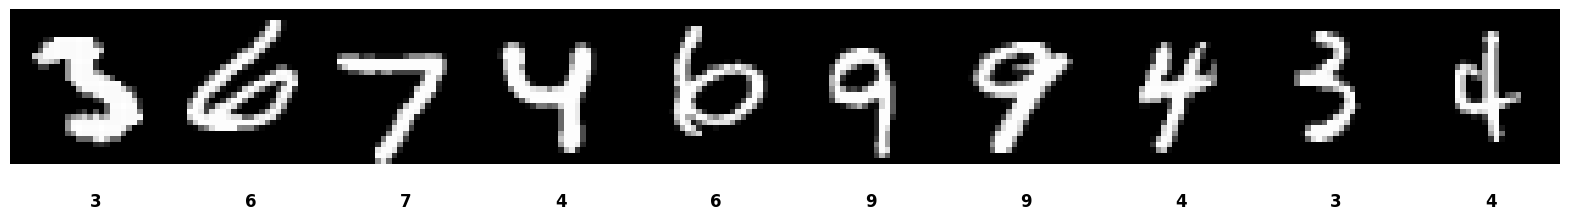

In [ ]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [ ]:
###################################
# Write your own code here #
# Normalización Min-Max (0 a 1) y redimensionamiento para la CNN
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encoding para la variable objetivo
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
###################################

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [ ]:
model = Sequential()
###################################
# Write your own code here #
# Capa convolucional (32 filtros, kernel 3x3) indicando la forma de entrada
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Capa de Max Pooling (ventana 2x2)
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanar los datos para la capa final
model.add(Flatten())

# Capa Densa de salida con 10 neuronas (clases del 0 al 9) y activación softmax
model.add(Dense(10, activation='softmax'))
###################################

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [ ]:
loss = 'categorical_crossentropy'
learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
metrics = ['accuracy']
###################################
# Write your own code here #
model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)
###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [ ]:
###################################
# Write your own code here #
epochs = 10
batch_size = 128

history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.2)
###################################

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8933 - loss: 0.3940 - val_accuracy: 0.9536 - val_loss: 0.1735
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9608 - loss: 0.1382 - val_accuracy: 0.9707 - val_loss: 0.1072
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9740 - loss: 0.0922 - val_accuracy: 0.9769 - val_loss: 0.0849
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.9789 - loss: 0.0735 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9824 - loss: 0.0630 - val_accuracy: 0.9802 - val_loss: 0.0710
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9840 - loss: 0.0559 - val_accuracy: 0.9805 - val_loss: 0.0713
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9851 - loss: 0.0509 - val_accuracy: 0.9818 - val_loss: 0.0654
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.9870 - loss: 0.0455 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

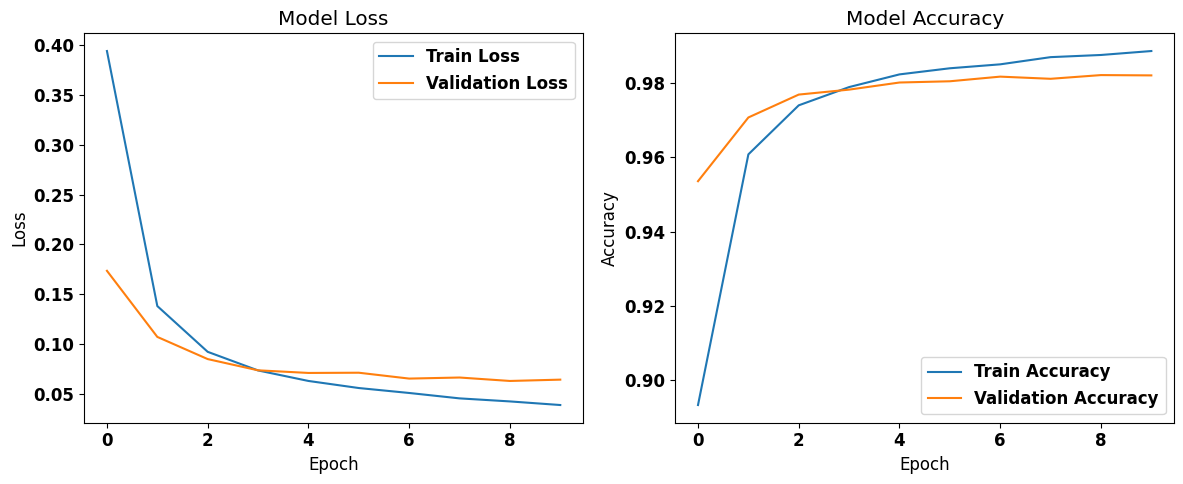

In [ ]:
###################################
# Write your own code here #
plt.figure(figsize=(12, 5))

# Gráfica de la función de pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Gráfica de la precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

Métricas en Test -> Loss: 0.0554 | Accuracy: 0.9829
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


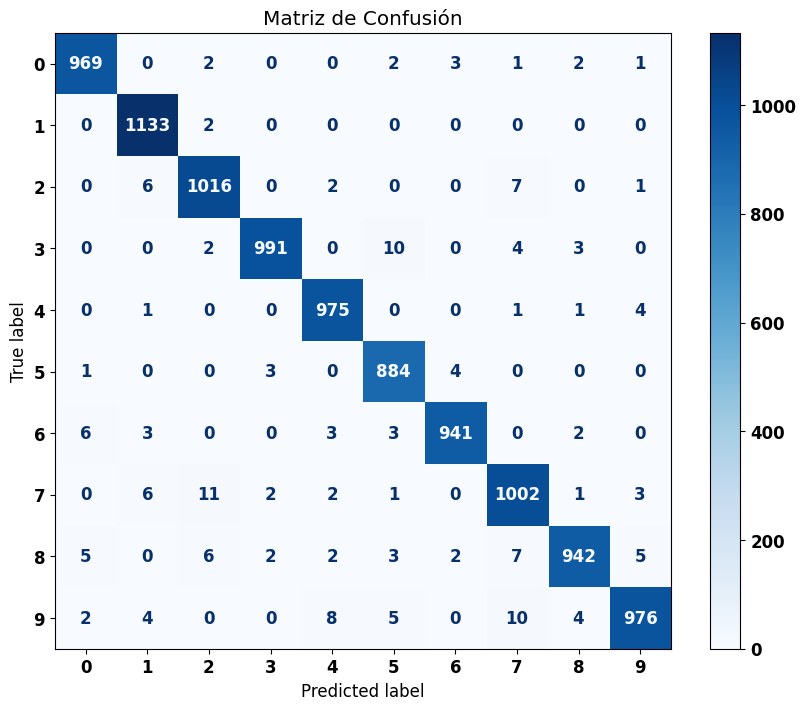

In [ ]:
###################################
# Write your own code here #
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Evaluar las métricas generales en el dataset de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Métricas en Test -> Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}")

# 2. Preparar los datos para la matriz de confusión
# El modelo devuelve probabilidades, así que tomamos la clase con mayor probabilidad (argmax)
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Crear y dibujar la matriz de confusión
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusión')
plt.show()
###################################

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

In [ ]:
###################################
# Write your own code here #
from keras.regularizers import l2

# Creamos un nuevo modelo intentando evitar el overfitting
model_tuned = Sequential()

# Primera capa convolucional + Pooling + Dropout
model_tuned.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_tuned.add(MaxPooling2D(pool_size=(2, 2)))
model_tuned.add(Dropout(0.25))

# Segunda capa convolucional para extraer patrones más complejos
model_tuned.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_tuned.add(MaxPooling2D(pool_size=(2, 2)))
model_tuned.add(Dropout(0.25))

model_tuned.add(Flatten())

# Capa densa con Regularización L2
model_tuned.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model_tuned.add(Dropout(0.5))

# Capa de salida
model_tuned.add(Dense(10, activation='softmax'))

# Compilamos
model_tuned.compile(loss='categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

# Entrenamos el nuevo modelo
print("Entrenando el modelo con regularización y dropout...")
history_tuned = model_tuned.fit(X_train, y_train,
                                batch_size=128,
                                epochs=10,
                                validation_split=0.2,
                                verbose=1)
###################################

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando el modelo con regularización y dropout...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 53s 130ms/step - accuracy: 0.8651 - loss: 0.5908 - val_accuracy: 0.9758 - val_loss: 0.2161
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 124ms/step - accuracy: 0.9544 - loss: 0.2584 - val_accuracy: 0.9798 - val_loss: 0.1601
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 117ms/step - accuracy: 0.9641 - loss: 0.2024 - val_accuracy: 0.9842 - val_loss: 0.1309
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9697 - loss: 0.1723 - val_accuracy: 0.9872 - val_loss: 0.1157
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - accuracy: 0.9708 - loss: 0.1639 - val_accuracy: 0.9866 - val_loss: 0.1136
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.9736 - loss: 0.1532 - val_accuracy: 0.9889 - val_loss: 0.1041
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.9746 - loss: 0.1461 - val_accuracy: 0.9887 - val_loss: 0.1076
Epoch 8/10
375/375 ━━━━━━━━━━━